# Notebook 06 — Feature Engineering & Preprocessing
**Project:** Climate-Driven Solar Energy Analytics
**Author:** BMSCE MCA Research Project

---

### Position in the pipeline

```
01_data_collection  →  02_data_understanding  →  03_seasonal_analysis
→  04_city_comparison  →  05_vif_outlier_analysis
→  [06_feature_engineering]  ← you are here
→  07_regression_models  →  08_xgboost  →  09_shap  →  10_recommender
```

### What this notebook does

This notebook bridges raw data to model-ready data. It has **five responsibilities**:

1. **Load & Reconstruct** — reload the master dataset and apply all decisions from Notebook 05
2. **Feature Engineering** — create `TEMP_RANGE`, `MONTH`, `SEASON`, `IS_MONSOON`, `log1p_PREC`
3. **Feature Selection** — lock in the Set C feature set confirmed by VIF Round 2
4. **Scaling** — apply `StandardScaler` (required for Ridge Regression; consistent across all models)
5. **Temporal Train/Test Split** — 2019–2022 train, 2023–2024 test (no data leakage)

### Key decisions carried forward from Notebook 05

| Decision | Detail |
|----------|--------|
| Drop | `T2M` — near-perfect linear combination of T2M_MAX and T2M_MIN |
| Drop | `T2M_MIN` — VIF Set B produced infinite values; Set C (without T2M_MIN) accepted |
| Keep | `T2M_MAX`, `TEMP_RANGE`, `RH2M`, `PS`, `WS10M`, `CLOUD_AMT`, `PRECTOTCORR` |
| No row deletion | Outlier rows carry fire-risk and grid-stress signal |
| Temporal split | 2019–2022 train / 2023–2024 test — weather is time-series data |


## Cell 1 — Imports & Project Constants

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
})
PALETTE = '#2563eb'

# ── Project constants (match notebooks 01–05 exactly) ────────────────────
RAW_DIR  = '../data/raw'
OUT_DIR  = '../outputs'
os.makedirs(OUT_DIR, exist_ok=True)

TARGET     = 'ALLSKY_SFC_SW_DWN'
SKIPROWS   = 17

CITY_NAMES = [
    'Ahmedabad', 'Bengaluru', 'Bhopal', 'Bhubaneswar', 'Chandigarh',
    'Chennai',   'Delhi',    'Guwahati', 'Hyderabad',  'Jaipur',
    'Kochi',     'Kolkata',  'Mangalore','Mumbai',     'Pune'
]

# IMD season classification (from notebook 03)
SEASON_MAP = {
    1: 'Winter',       2: 'Winter',      12: 'Winter',
    3: 'Pre-Monsoon',  4: 'Pre-Monsoon',  5: 'Pre-Monsoon',
    6: 'Monsoon',      7: 'Monsoon',      8: 'Monsoon',    9: 'Monsoon',
    10: 'Post-Monsoon', 11: 'Post-Monsoon'
}
SEASON_ORDER = ['Winter', 'Pre-Monsoon', 'Monsoon', 'Post-Monsoon']

# ── VIF-confirmed feature set from Notebook 05 (Set C) ───────────────────
# T2M dropped  : near-perfect linear combination → VIF infinite
# T2M_MIN dropped: in Set B (with TEMP_RANGE) → VIF infinite
# TEMP_RANGE added: engineered DTR predictor — independent, VIF < 5
FINAL_FEATURES = [
    'T2M_MAX',       # max daily temp — heat-wave signal, VIF < 5 in Set C
    'TEMP_RANGE',    # T2M_MAX - T2M_MIN — DTR predictor
    'RH2M',          # relative humidity — negative GHI predictor
    'PS',            # surface pressure — elevation proxy
    'WS10M',         # wind speed — cloud dispersal signal
    'CLOUD_AMT',     # cloud amount — strongest single GHI predictor
    'PRECTOTCORR',   # precipitation — monsoon signal
]

print('✓ Notebook 06 initialised')
print(f'  Final features : {FINAL_FEATURES}')
print(f'  Target         : {TARGET}')
print(f'  Cities         : {len(CITY_NAMES)}')


✓ Notebook 06 initialised
  Final features : ['T2M_MAX', 'TEMP_RANGE', 'RH2M', 'PS', 'WS10M', 'CLOUD_AMT', 'PRECTOTCORR']
  Target         : ALLSKY_SFC_SW_DWN
  Cities         : 15


## Cell 2 — Load & Merge All 15 City CSVs

Exact loading pattern from Notebooks 01–05: explicit `CITY_NAMES` list, `skiprows=17`, `-999` treated as NaN.

In [2]:
dfs = []

for city in CITY_NAMES:
    path = os.path.join(RAW_DIR, f'{city}.csv')
    df   = pd.read_csv(path, skiprows=SKIPROWS, na_values=['-999', -999])

    df['date'] = pd.to_datetime(
        df['YEAR'].astype(str) + '-'
        + df['MO'].astype(str).str.zfill(2) + '-'
        + df['DY'].astype(str).str.zfill(2)
    )
    df['city'] = city
    dfs.append(df)

master = pd.concat(dfs, ignore_index=True)
master = master.sort_values(['city', 'date']).reset_index(drop=True)

# Retain only useful raw columns
raw_cols = ['date', 'city', 'T2M', 'T2M_MAX', 'T2M_MIN',
            'RH2M', 'PS', 'WS10M', 'CLOUD_AMT', 'PRECTOTCORR', TARGET]
master = master[[c for c in raw_cols if c in master.columns]]

print(f'Master shape   : {master.shape}')
print(f'Cities         : {master["city"].nunique()}')
print(f'Date range     : {master["date"].min().date()} → {master["date"].max().date()}')
print(f'Missing values : {master.isnull().sum().sum()}')
master.head(3)


Master shape   : (32880, 11)
Cities         : 15
Date range     : 2019-01-01 → 2024-12-31
Missing values : 0


,date,city,T2M,T2M_MAX,T2M_MIN,RH2M,PS,WS10M,CLOUD_AMT,PRECTOTCORR,ALLSKY_SFC_SW_DWN
0,2019-01-01,Ahmedabad,20.11,31.21,10.91,12.37,101.27,2.60,0.37,0.0,4.7508
1,2019-01-02,Ahmedabad,20.46,31.36,11.56,13.13,101.26,2.87,0.18,0.0,4.8002
2,2019-01-03,Ahmedabad,19.71,30.61,10.84,18.30,101.39,3.04,3.71,0.0,4.8130


## Cell 3 — Drop NaN Rows & Record Count

We drop rows with missing values in ANY model-relevant column. Notebook 05 confirmed the
count was negligible (< 0.1 %). We record the before/after so this is reproducible.


In [3]:
model_cols = ['T2M_MAX', 'T2M_MIN', 'RH2M', 'PS',
              'WS10M', 'CLOUD_AMT', 'PRECTOTCORR', TARGET]

before  = len(master)
df_work = master.dropna(subset=model_cols).copy()
after   = len(df_work)

print(f'Rows before NaN drop : {before:,}')
print(f'Rows dropped         : {before - after:,}  ({(before - after)/before*100:.3f}%)')
print(f'Rows remaining       : {after:,}')
print()
print('No rows deleted for outliers — confirmed in Notebook 05.')
print('Outlier rows carry fire-risk and grid-stress labels.')


Rows before NaN drop : 32,880
Rows dropped         : 0  (0.000%)
Rows remaining       : 32,880

No rows deleted for outliers — confirmed in Notebook 05.
Outlier rows carry fire-risk and grid-stress labels.


## Cell 4 — Feature Engineering

### 4a. TEMP_RANGE (confirmed in Notebook 05)

**Diurnal Temperature Range** = `T2M_MAX − T2M_MIN`

Physical basis (Hargreaves & Samani, 1982):
- Large DTR → clear sky, low humidity, high GHI
- Small DTR → overcast / monsoon, low GHI

VIF in Set C (Notebook 05): **< 5** ✓


In [4]:
# ── 4a. TEMP_RANGE ───────────────────────────────────────────────────────
df_work['TEMP_RANGE'] = (
    df_work['T2M_MAX'] - df_work['T2M_MIN']
)

# Notebook 05 VIF decision:
# T2M_MIN is used only to create TEMP_RANGE
# and must not be passed to any model.
df_work.drop(columns=['T2M_MIN'], inplace=True)

assert 'T2M_MIN' not in df_work.columns

r_tr = df_work[['TEMP_RANGE', TARGET]].corr().iloc[0, 1]


### 4b. Time Features — MONTH, YEAR, DAY_OF_YEAR, SEASON, IS_MONSOON

Month and season were identified as important cyclical features in Notebook 03. The year-month heatmap confirmed a consistent annual pattern across all 6 years.

In [5]:
# ── 4b. Time features ────────────────────────────────────────────────────
df_work['MONTH']      = df_work['date'].dt.month
df_work['YEAR_NUM']   = df_work['date'].dt.year
df_work['DAY_OF_YEAR']= df_work['date'].dt.dayofyear
df_work['SEASON']     = df_work['MONTH'].map(SEASON_MAP)
df_work['IS_MONSOON'] = (df_work['SEASON'] == 'Monsoon').astype(int)

print('Time features created:')
print(f'  MONTH range      : {df_work["MONTH"].min()} – {df_work["MONTH"].max()}')
print(f'  YEAR_NUM range   : {df_work["YEAR_NUM"].min()} – {df_work["YEAR_NUM"].max()}')
print(f'  IS_MONSOON dist  : {df_work["IS_MONSOON"].value_counts().to_dict()}')
print()
print('Season distribution:')
print(df_work["SEASON"].value_counts().reindex(SEASON_ORDER))


Time features created:
  MONTH range      : 1 – 12
  YEAR_NUM range   : 2019 – 2024
  IS_MONSOON dist  : {0: 21900, 1: 10980}

Season distribution:
SEASON
Winter           8130
Pre-Monsoon      8280
Monsoon         10980
Post-Monsoon     5490
Name: count, dtype: int64


### 4c. log1p(PRECTOTCORR) — Handle Right-Skewed Rainfall

Precipitation is strongly right-skewed (identified in Notebook 02). The `log1p` transform (log(1+x)) compresses the tail while handling zero-rain days correctly.

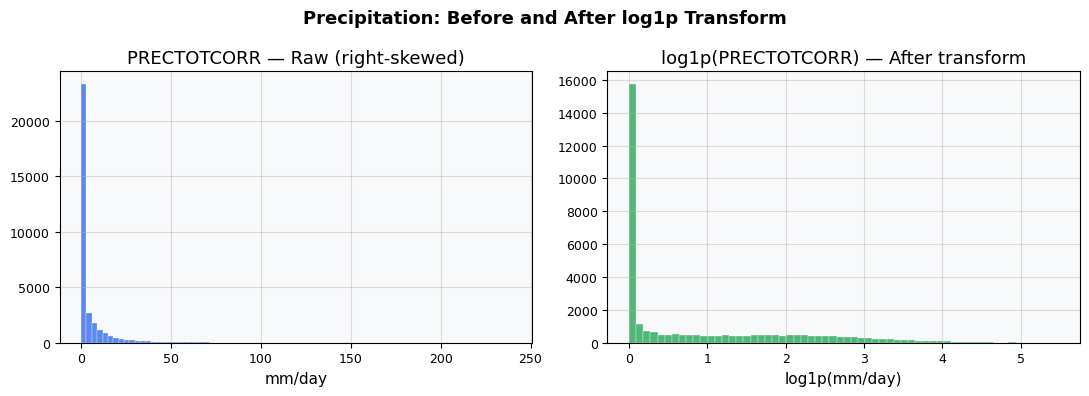

Skewness before : 5.060
Skewness after  : 1.141
Skewness reduced by 77.4%


In [6]:
# ── 4c. Log-transform precipitation ──────────────────────────────────────
df_work['log1p_PREC'] = np.log1p(df_work['PRECTOTCORR'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df_work['PRECTOTCORR'], bins=80, color=PALETTE, alpha=0.75,
             edgecolor='white', linewidth=0.3)
axes[0].set_title('PRECTOTCORR — Raw (right-skewed)')
axes[0].set_xlabel('mm/day')

axes[1].hist(df_work['log1p_PREC'], bins=60, color='#16a34a', alpha=0.75,
             edgecolor='white', linewidth=0.3)
axes[1].set_title('log1p(PRECTOTCORR) — After transform')
axes[1].set_xlabel('log1p(mm/day)')

plt.suptitle('Precipitation: Before and After log1p Transform', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'prec_log_transform.png'), dpi=150, bbox_inches='tight')
plt.show()

skew_raw  = df_work['PRECTOTCORR'].skew()
skew_log  = df_work['log1p_PREC'].skew()
print(f'Skewness before : {skew_raw:.3f}')
print(f'Skewness after  : {skew_log:.3f}')
print(f'Skewness reduced by {abs(skew_raw - skew_log) / abs(skew_raw) * 100:.1f}%')


### 4d. Cyclical Encoding of MONTH

Month 1 and Month 12 are consecutive in the calendar but 11 apart numerically. Sine/cosine encoding wraps the month axis into a circle so the model sees January and December as close together.

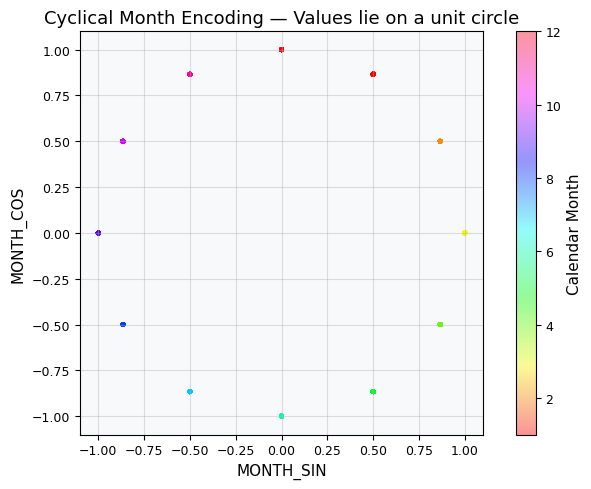

Cyclical encoding created: MONTH_SIN, MONTH_COS
Month 1 (Jan) and Month 12 (Dec) are now adjacent in this space.


In [7]:
# ── 4d. Cyclical month encoding ──────────────────────────────────────────
df_work['MONTH_SIN'] = np.sin(2 * np.pi * df_work['MONTH'] / 12)
df_work['MONTH_COS'] = np.cos(2 * np.pi * df_work['MONTH'] / 12)

# Verify the encoding wraps correctly
fig, ax = plt.subplots(figsize=(7, 5))
sample = df_work[df_work['city'] == 'Bengaluru'].sort_values('date')
sc = ax.scatter(sample['MONTH_SIN'], sample['MONTH_COS'],
                c=sample['MONTH'], cmap='hsv', s=6, alpha=0.4)
plt.colorbar(sc, ax=ax, label='Calendar Month')
ax.set_xlabel('MONTH_SIN')
ax.set_ylabel('MONTH_COS')
ax.set_title('Cyclical Month Encoding — Values lie on a unit circle')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'month_cyclical_encoding.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Cyclical encoding created: MONTH_SIN, MONTH_COS')
print('Month 1 (Jan) and Month 12 (Dec) are now adjacent in this space.')


In [8]:
# ── 4e. City Encoding ─────────────────────────────────────────────

city_dummies = pd.get_dummies(
    df_work['city'],
    prefix='CITY',
    dtype=int
)

df_work = pd.concat(
    [df_work, city_dummies],
    axis=1
)

CITY_FEATURES = sorted(
    [c for c in city_dummies.columns]
)

print(f'City features created: {len(CITY_FEATURES)}')
print(CITY_FEATURES)

City features created: 15
['CITY_Ahmedabad', 'CITY_Bengaluru', 'CITY_Bhopal', 'CITY_Bhubaneswar', 'CITY_Chandigarh', 'CITY_Chennai', 'CITY_Delhi', 'CITY_Guwahati', 'CITY_Hyderabad', 'CITY_Jaipur', 'CITY_Kochi', 'CITY_Kolkata', 'CITY_Mangalore', 'CITY_Mumbai', 'CITY_Pune']


## Cell 5 — Final Feature Set Definition

We lock in two model variants for Notebooks 07–09:

| Variant | Features | Use |
|---------|----------|-----|
| **Core** | VIF Set C + log1p_PREC | Regression & XGBoost |
| **Extended** | Core + MONTH_SIN, MONTH_COS, IS_MONSOON, DAY_OF_YEAR | Time-aware models |


In [9]:
# ── CORE feature set (from VIF Set C + log-transformed precipitation) ────
FEATURES_CORE = [
    'T2M_MAX',
    'TEMP_RANGE',
    'RH2M',
    'PS',
    'WS10M',
    'CLOUD_AMT',
    'log1p_PREC',   # replaces raw PRECTOTCORR
]

# ── EXTENDED feature set (adds temporal context) ──────────────────────────
FEATURES_TEMPORAL = [
    'MONTH_SIN',
    'MONTH_COS',
    'IS_MONSOON',
    'DAY_OF_YEAR'
]

FEATURES_EXTENDED = (
    FEATURES_CORE
    + FEATURES_TEMPORAL
    + CITY_FEATURES
)

print('FEATURES_CORE    :', FEATURES_CORE)
print()
print('FEATURES_EXTENDED:', FEATURES_EXTENDED)
print()
print(f'Core     : {len(FEATURES_CORE)} features')
print(f'Extended : {len(FEATURES_EXTENDED)} features')

# Verify all features exist in the dataframe
missing_features = []

for f in FEATURES_EXTENDED:
    if f in df_work.columns:
        print(f'  ✓  {f}')
    else:
        print(f'  ✗ MISSING  {f}')
        missing_features.append(f)

assert len(missing_features) == 0, (
    f"Missing features: {missing_features}"
)
    
print()
print("Verification Checks")

assert 'T2M_MIN' not in FEATURES_EXTENDED
assert 'T2M_MIN' not in df_work.columns

print("✓ T2M_MIN removed")
print("✓ VIF decision preserved")
print("✓ City encoding included")

FEATURES_CORE    : ['T2M_MAX', 'TEMP_RANGE', 'RH2M', 'PS', 'WS10M', 'CLOUD_AMT', 'log1p_PREC']

FEATURES_EXTENDED: ['T2M_MAX', 'TEMP_RANGE', 'RH2M', 'PS', 'WS10M', 'CLOUD_AMT', 'log1p_PREC', 'MONTH_SIN', 'MONTH_COS', 'IS_MONSOON', 'DAY_OF_YEAR', 'CITY_Ahmedabad', 'CITY_Bengaluru', 'CITY_Bhopal', 'CITY_Bhubaneswar', 'CITY_Chandigarh', 'CITY_Chennai', 'CITY_Delhi', 'CITY_Guwahati', 'CITY_Hyderabad', 'CITY_Jaipur', 'CITY_Kochi', 'CITY_Kolkata', 'CITY_Mangalore', 'CITY_Mumbai', 'CITY_Pune']

Core     : 7 features
Extended : 26 features
  ✓  T2M_MAX
  ✓  TEMP_RANGE
  ✓  RH2M
  ✓  PS
  ✓  WS10M
  ✓  CLOUD_AMT
  ✓  log1p_PREC
  ✓  MONTH_SIN
  ✓  MONTH_COS
  ✓  IS_MONSOON
  ✓  DAY_OF_YEAR
  ✓  CITY_Ahmedabad
  ✓  CITY_Bengaluru
  ✓  CITY_Bhopal
  ✓  CITY_Bhubaneswar
  ✓  CITY_Chandigarh
  ✓  CITY_Chennai
  ✓  CITY_Delhi
  ✓  CITY_Guwahati
  ✓  CITY_Hyderabad
  ✓  CITY_Jaipur
  ✓  CITY_Kochi
  ✓  CITY_Kolkata
  ✓  CITY_Mangalore
  ✓  CITY_Mumbai
  ✓  CITY_Pune

Verification Checks
✓ T2M_MIN rem

## Cell 6 — Temporal Train / Test Split

### Why temporal split — NOT random split

Our data is a **time series**. A random split would allow the model to train on
observations from 2023 and then be tested on observations from 2021 — this constitutes
**data leakage**: the model learns future patterns that wouldn't be available in deployment.

**Split boundary:**
- **Train:** 2019–2022 (4 years, ~80% of data)
- **Test:** 2023–2024 (2 years, ~20% of data)

This mirrors real-world deployment: you train on historical data and predict for the next period.


In [10]:
TRAIN_YEARS = [2019, 2020, 2021, 2022]
TEST_YEARS  = [2023, 2024]

mask_train = df_work['YEAR_NUM'].isin(TRAIN_YEARS)
mask_test  = df_work['YEAR_NUM'].isin(TEST_YEARS)

train_df = df_work[mask_train].copy()
test_df  = df_work[mask_test].copy()

print(f'Train set : {len(train_df):,} rows  | Years: {TRAIN_YEARS}')
print(f'Test set  : {len(test_df):,} rows   | Years: {TEST_YEARS}')
print(f'Train %   : {len(train_df)/len(df_work)*100:.1f}%')
print(f'Test %    : {len(test_df)/len(df_work)*100:.1f}%')
print()

# Verify no date overlap
assert train_df['date'].max() < test_df['date'].min(), 'Date overlap detected!'
print(f'Train ends   : {train_df["date"].max().date()}')
print(f'Test starts  : {test_df["date"].min().date()}')
print('✓ No temporal overlap confirmed')


Train set : 21,915 rows  | Years: [2019, 2020, 2021, 2022]
Test set  : 10,965 rows   | Years: [2023, 2024]
Train %   : 66.7%
Test %    : 33.3%

Train ends   : 2022-12-31
Test starts  : 2023-01-01
✓ No temporal overlap confirmed


## Cell 7 — Verify Split Preserves Season Distribution

If the split were skewed (e.g. test set has more monsoon months), performance metrics would be misleading. We check that all four Indian seasons are proportionally represented in both sets.

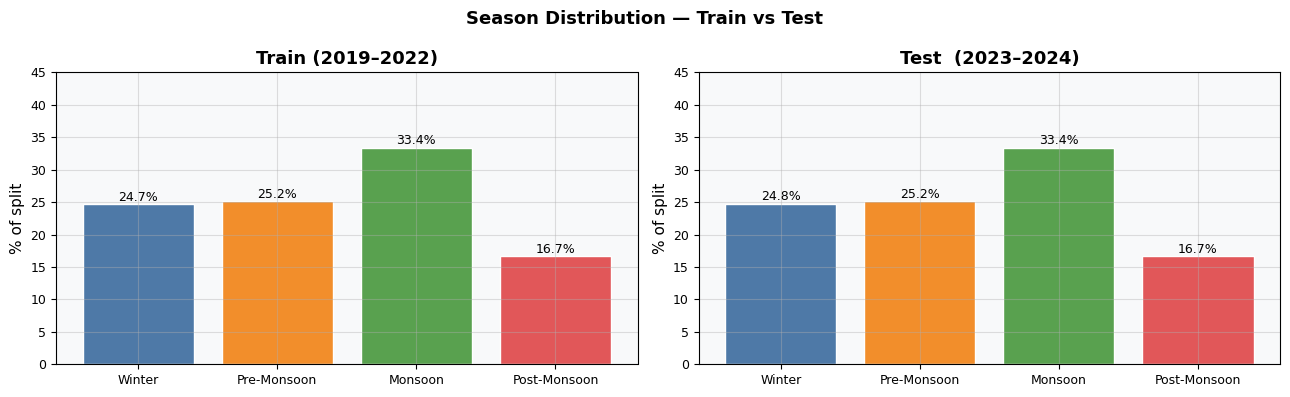

Season proportions (%) — Train vs Test:
Season              Train     Test
----------------------------------
Winter              24.7%    24.8%
Pre-Monsoon         25.2%    25.2%
Monsoon             33.4%    33.4%
Post-Monsoon        16.7%    16.7%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (label, subset) in zip(axes, [('Train (2019–2022)', train_df),
                                        ('Test  (2023–2024)', test_df)]):
    season_pct = (
        subset.groupby('SEASON')[TARGET]
        .count()
        .reindex(SEASON_ORDER)
        / len(subset) * 100
    )
    colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']
    bars = ax.bar(season_pct.index, season_pct.values, color=colors, edgecolor='white')
    for bar, val in zip(bars, season_pct.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('% of split')
    ax.set_ylim(0, 45)

plt.suptitle('Season Distribution — Train vs Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'split_season_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# Statistical check
print('Season proportions (%) — Train vs Test:')
print(f'{"Season":<16} {"Train":>8} {"Test":>8}')
print('-' * 34)
for season in SEASON_ORDER:
    tr_pct = (train_df['SEASON'] == season).mean() * 100
    te_pct = (test_df['SEASON'] == season).mean() * 100
    flag = '  ⚠' if abs(tr_pct - te_pct) > 5 else ''
    print(f'{season:<16} {tr_pct:>7.1f}% {te_pct:>7.1f}%{flag}')


## Cell 8 — StandardScaler

### Why scale?

| Model | Needs scaling? | Reason |
|-------|---------------|--------|
| Linear Regression | Yes | Coefficient magnitude depends on feature scale |
| Ridge Regression | **Critical** | Penalty term treats all features equally only if scaled |
| Random Forest | Not needed | Tree splits are scale-invariant |
| XGBoost | Not needed | Same as Random Forest |
| SVM (future) | **Critical** | RBF kernel is distance-based |

We scale anyway for all models to ensure fair feature importance comparison.

**Critical rule:** The scaler is **fit on the training set only**. Fitting on the full dataset would leak test-set statistics into training — a form of data leakage.


In [12]:
# ── Fit scaler on TRAIN only ──────────────────────────────────────────────
scaler = StandardScaler()

X_train = train_df[FEATURES_EXTENDED].values
X_test  = test_df[FEATURES_EXTENDED].values
y_train = train_df[TARGET].values
y_test  = test_df[TARGET].values

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)        # transform ONLY — no fit

print('Scaler fit on training set only ✓')
print(f'  X_train shape : {X_train_scaled.shape}')
print(f'  X_test  shape : {X_test_scaled.shape}')
print(f'  y_train shape : {y_train.shape}')
print(f'  y_test  shape : {y_test.shape}')
print()
print('Scaler parameters (learned from train only):')
scaler_df = pd.DataFrame({
    'Feature': FEATURES_EXTENDED,
    'Train_Mean': scaler.mean_.round(4),
    'Train_Std':  np.sqrt(scaler.var_).round(4)
})
print(scaler_df.to_string(index=False))


Scaler fit on training set only ✓
  X_train shape : (21915, 26)
  X_test  shape : (10965, 26)
  y_train shape : (21915,)
  y_test  shape : (10965,)

Scaler parameters (learned from train only):
         Feature  Train_Mean  Train_Std
         T2M_MAX     31.1778     5.2973
      TEMP_RANGE     10.2553     4.7141
            RH2M     67.2031    20.5484
              PS     97.5876     2.7553
           WS10M      3.1639     1.3482
       CLOUD_AMT     53.6572    34.1967
      log1p_PREC      0.8967     1.1639
       MONTH_SIN     -0.0048     0.7058
       MONTH_COS     -0.0020     0.7084
      IS_MONSOON      0.3340     0.4716
     DAY_OF_YEAR    183.1253   105.4386
  CITY_Ahmedabad      0.0667     0.2494
  CITY_Bengaluru      0.0667     0.2494
     CITY_Bhopal      0.0667     0.2494
CITY_Bhubaneswar      0.0667     0.2494
 CITY_Chandigarh      0.0667     0.2494
    CITY_Chennai      0.0667     0.2494
      CITY_Delhi      0.0667     0.2494
   CITY_Guwahati      0.0667     0.2494
  CITY

## Cell 9 — Verify Scaling: Before vs After Distributions

After scaling every feature should have mean ≈ 0 and std ≈ 1 (on the training set). We verify this visually.

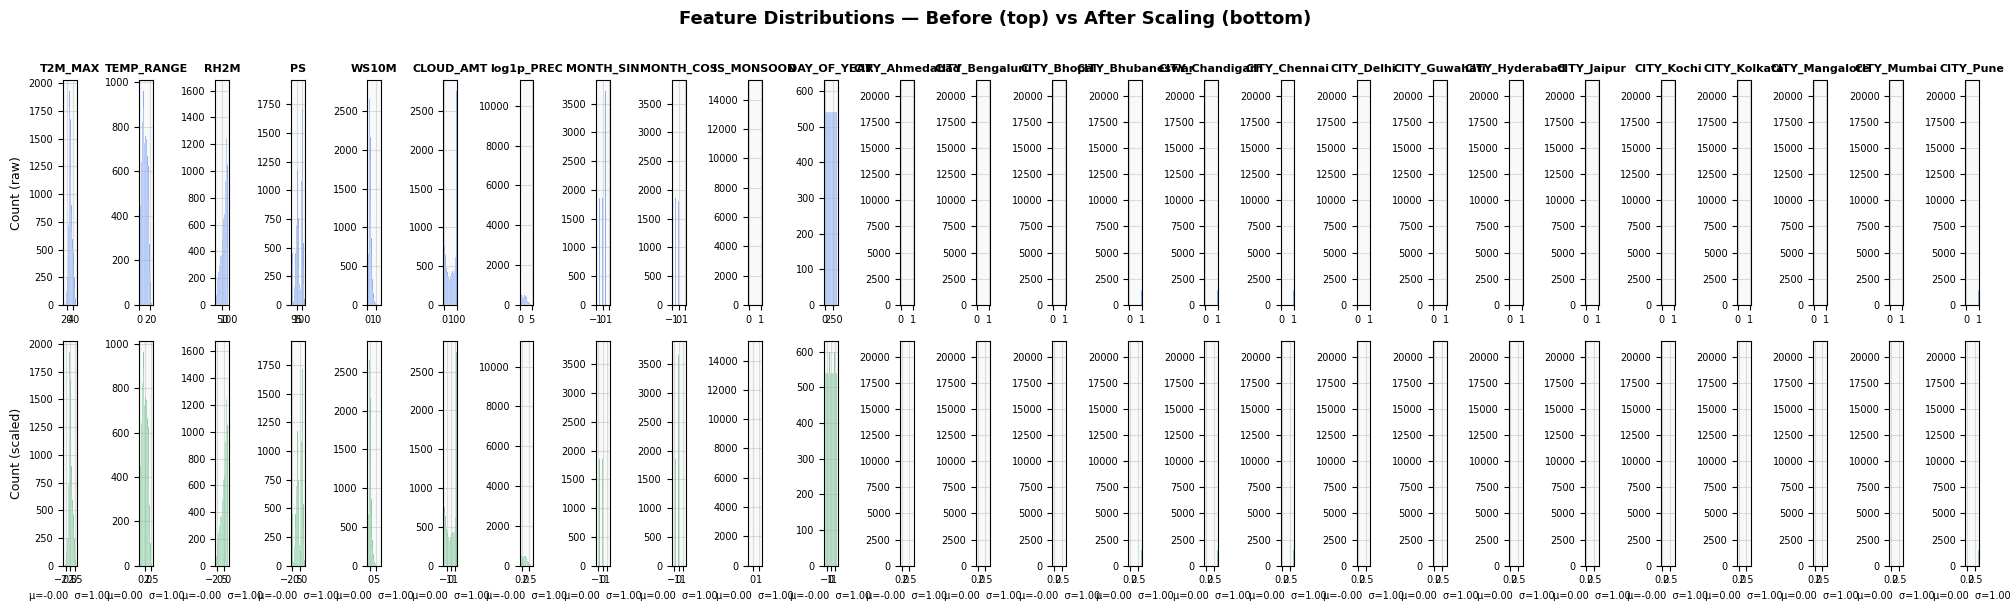

Mean and std after scaling (training set):
  T2M_MAX           mean=-0.0000  std=1.0000
  TEMP_RANGE        mean=+0.0000  std=1.0000
  RH2M              mean=-0.0000  std=1.0000
  PS                mean=-0.0000  std=1.0000
  WS10M             mean=+0.0000  std=1.0000
  CLOUD_AMT         mean=+0.0000  std=1.0000
  log1p_PREC        mean=-0.0000  std=1.0000
  MONTH_SIN         mean=+0.0000  std=1.0000
  MONTH_COS         mean=+0.0000  std=1.0000
  IS_MONSOON        mean=+0.0000  std=1.0000
  DAY_OF_YEAR       mean=-0.0000  std=1.0000
  CITY_Ahmedabad    mean=-0.0000  std=1.0000
  CITY_Bengaluru    mean=+0.0000  std=1.0000
  CITY_Bhopal       mean=-0.0000  std=1.0000
  CITY_Bhubaneswar  mean=+0.0000  std=1.0000
  CITY_Chandigarh   mean=+0.0000  std=1.0000
  CITY_Chennai      mean=+0.0000  std=1.0000
  CITY_Delhi        mean=-0.0000  std=1.0000
  CITY_Guwahati     mean=+0.0000  std=1.0000
  CITY_Hyderabad    mean=+0.0000  std=1.0000
  CITY_Jaipur       mean=+0.0000  std=1.0000
  CITY_Kochi

In [13]:
fig, axes = plt.subplots(2, len(FEATURES_EXTENDED), figsize=(20, 6))
fig.suptitle('Feature Distributions — Before (top) vs After Scaling (bottom)',
             fontsize=13, fontweight='bold', y=1.01)

for i, feat in enumerate(FEATURES_EXTENDED):
    # Before
    axes[0, i].hist(train_df[feat].dropna(), bins=40,
                    color=PALETTE, alpha=0.7, edgecolor='white', linewidth=0.3)
    axes[0, i].set_title(feat, fontsize=8, fontweight='bold')
    axes[0, i].tick_params(labelsize=7)

    # After
    axes[1, i].hist(X_train_scaled[:, i], bins=40,
                    color='#16a34a', alpha=0.7, edgecolor='white', linewidth=0.3)
    axes[1, i].tick_params(labelsize=7)
    axes[1, i].set_xlabel(f'μ={X_train_scaled[:,i].mean():.2f}  σ={X_train_scaled[:,i].std():.2f}',
                          fontsize=7)

axes[0, 0].set_ylabel('Count (raw)', fontsize=9)
axes[1, 0].set_ylabel('Count (scaled)', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'scaling_before_after.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Mean and std after scaling (training set):')
for i, feat in enumerate(FEATURES_EXTENDED):
    m = X_train_scaled[:, i].mean()
    s = X_train_scaled[:, i].std()
    print(f'  {feat:<16}  mean={m:+.4f}  std={s:.4f}')


## Cell 10 — Also Prepare Core Feature Arrays

We create both Core and Extended arrays so downstream notebooks can choose:
- `FEATURES_CORE` for interpretable baselines
- `FEATURES_EXTENDED` for full-context models


In [14]:
scaler_core = StandardScaler()

X_train_core = train_df[FEATURES_CORE].values
X_test_core  = test_df[FEATURES_CORE].values

X_train_core_scaled = scaler_core.fit_transform(X_train_core)
X_test_core_scaled  = scaler_core.transform(X_test_core)

print(f'Core arrays:')
print(f'  X_train_core_scaled : {X_train_core_scaled.shape}')
print(f'  X_test_core_scaled  : {X_test_core_scaled.shape}')
print()
print(f'Extended arrays:')
print(f'  X_train_scaled      : {X_train_scaled.shape}')
print(f'  X_test_scaled       : {X_test_scaled.shape}')


Core arrays:
  X_train_core_scaled : (21915, 7)
  X_test_core_scaled  : (10965, 7)

Extended arrays:
  X_train_scaled      : (21915, 26)
  X_test_scaled       : (10965, 26)


## Cell 11 — Target Variable Analysis

Before modelling we verify the target (`ALLSKY_SFC_SW_DWN`) distribution in train and test sets. A large shift between train and test would mean the split is not representative.

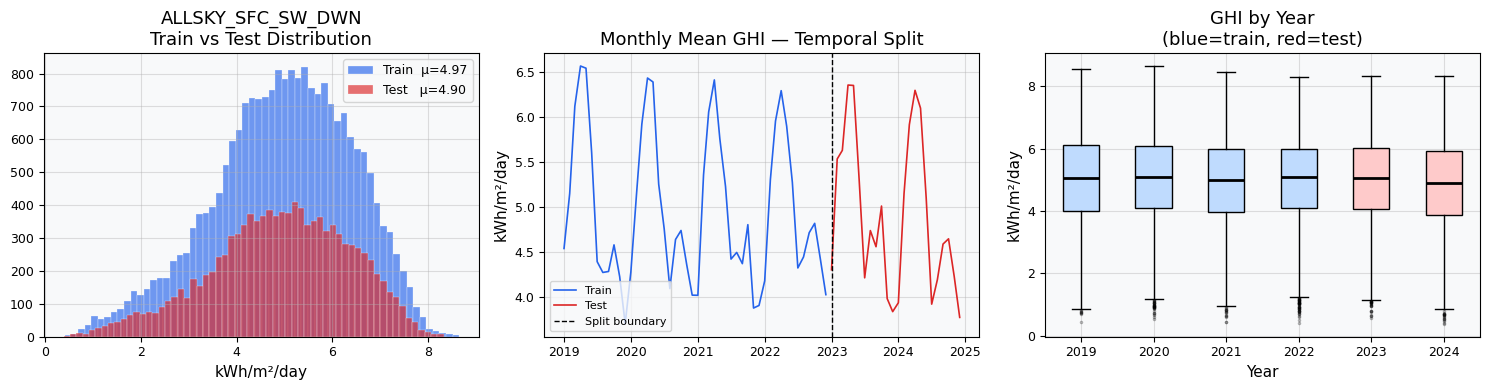

Target statistics:
  Train  — mean: 4.9654  std: 1.4423  min: 0.41  max: 8.65
  Test   — mean: 4.9007  std: 1.4454  min: 0.38  max: 8.33
  Mean shift     : 0.0647 kWh/m²/day ✓ acceptable


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution comparison
axes[0].hist(y_train, bins=60, alpha=0.65, color='#2563eb',
             edgecolor='white', linewidth=0.3, label=f'Train  μ={y_train.mean():.2f}')
axes[0].hist(y_test, bins=60, alpha=0.65, color='#dc2626',
             edgecolor='white', linewidth=0.3, label=f'Test   μ={y_test.mean():.2f}')
axes[0].set_title(f'{TARGET}\nTrain vs Test Distribution')
axes[0].set_xlabel('kWh/m²/day')
axes[0].legend(fontsize=9)

# Time series of monthly mean
df_work['ym'] = df_work['date'].dt.to_period('M')
monthly = df_work.groupby(['ym', 'YEAR_NUM'])[TARGET].mean().reset_index()
monthly['ym_dt'] = monthly['ym'].dt.to_timestamp()

axes[1].plot(monthly[monthly['YEAR_NUM'].isin(TRAIN_YEARS)]['ym_dt'],
             monthly[monthly['YEAR_NUM'].isin(TRAIN_YEARS)][TARGET],
             color='#2563eb', linewidth=1.2, label='Train')
axes[1].plot(monthly[monthly['YEAR_NUM'].isin(TEST_YEARS)]['ym_dt'],
             monthly[monthly['YEAR_NUM'].isin(TEST_YEARS)][TARGET],
             color='#dc2626', linewidth=1.2, label='Test')
axes[1].axvline(pd.Timestamp('2023-01-01'), color='black',
                linestyle='--', linewidth=1, label='Split boundary')
axes[1].set_title('Monthly Mean GHI — Temporal Split')
axes[1].set_ylabel('kWh/m²/day')
axes[1].legend(fontsize=8)

# Boxplot by year
years_data = [df_work[df_work['YEAR_NUM'] == y][TARGET].values for y in range(2019, 2025)]
bp = axes[2].boxplot(years_data, labels=range(2019, 2025), patch_artist=True,
                      medianprops=dict(color='black', linewidth=2),
                      flierprops=dict(marker='o', markersize=1.5, alpha=0.3))
for i, (patch, year) in enumerate(zip(bp['boxes'], range(2019, 2025))):
    patch.set_facecolor('#bfdbfe' if year <= 2022 else '#fecaca')
axes[2].set_title('GHI by Year\n(blue=train, red=test)')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('kWh/m²/day')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'target_split_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Target statistics:')
print(f'  Train  — mean: {y_train.mean():.4f}  std: {y_train.std():.4f}  '
      f'min: {y_train.min():.2f}  max: {y_train.max():.2f}')
print(f'  Test   — mean: {y_test.mean():.4f}  std: {y_test.std():.4f}  '
      f'min: {y_test.min():.2f}  max: {y_test.max():.2f}')
mean_shift = abs(y_train.mean() - y_test.mean())
print(f'  Mean shift     : {mean_shift:.4f} kWh/m²/day', '✓ acceptable' if mean_shift < 0.3 else '⚠ large — check split')


## Cell 12 — Feature Correlation with Target (Engineered Set)

After engineering, we recheck how each feature correlates with `ALLSKY_SFC_SW_DWN`.
This gives a quick sanity check that engineered features (TEMP_RANGE, log1p_PREC, IS_MONSOON)
have the expected direction and strength.


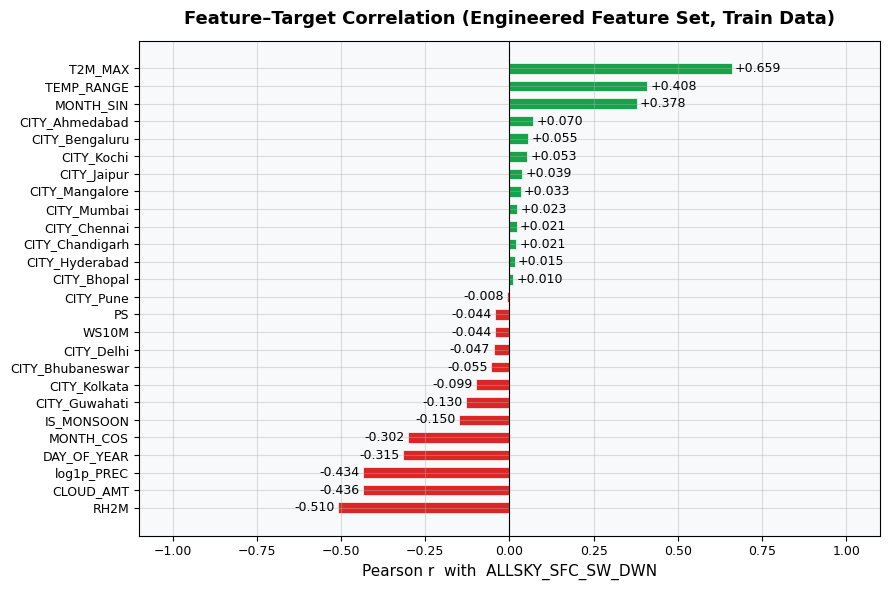

Top positive predictors:
T2M_MAX            0.659303
TEMP_RANGE         0.407713
MONTH_SIN          0.377624
CITY_Ahmedabad     0.069612
CITY_Bengaluru     0.054703
CITY_Kochi         0.053255
CITY_Jaipur        0.038535
CITY_Mangalore     0.033154
CITY_Mumbai        0.023007
CITY_Chennai       0.020984
CITY_Chandigarh    0.020635
CITY_Hyderabad     0.015424
CITY_Bhopal        0.010003

Top negative predictors:
RH2M               -0.509798
CLOUD_AMT          -0.435869
log1p_PREC         -0.434453
DAY_OF_YEAR        -0.314696
MONTH_COS          -0.301527
IS_MONSOON         -0.150162
CITY_Guwahati      -0.130067
CITY_Kolkata       -0.099220
CITY_Bhubaneswar   -0.054742
CITY_Delhi         -0.047417
WS10M              -0.044317
PS                 -0.044102
CITY_Pune          -0.007867


In [16]:
corr_feats = FEATURES_EXTENDED + [TARGET]
corr_vals  = (
    train_df[corr_feats]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values()
)

colors = ['#dc2626' if v < 0 else '#16a34a' for v in corr_vals]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(corr_vals.index, corr_vals.values, color=colors,
               edgecolor='white', linewidth=0.5, height=0.6)

for bar, val in zip(bars, corr_vals.values):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(f'Pearson r  with  {TARGET}', fontsize=11)
ax.set_title('Feature–Target Correlation (Engineered Feature Set, Train Data)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(-1.1, 1.1)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'feature_target_correlation_engineered.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('Top positive predictors:')
print(corr_vals[corr_vals > 0].sort_values(ascending=False).to_string())
print()
print('Top negative predictors:')
print(corr_vals[corr_vals < 0].sort_values().to_string())


## Cell 13 — Save Preprocessed Data to CSV

All downstream notebooks load these files instead of re-running preprocessing.

In [17]:
# Build the save dataframes (unscaled — models can scale themselves or use pre-scaled arrays)
save_cols = ['date', 'city', 'YEAR_NUM', 'MONTH', 'SEASON'] + FEATURES_EXTENDED + [TARGET]

train_save = train_df[[c for c in save_cols if c in train_df.columns]].copy()
test_save  = test_df[[c for c in save_cols if c in test_df.columns]].copy()

train_path = os.path.join(OUT_DIR, 'train_preprocessed.csv')
test_path  = os.path.join(OUT_DIR, 'test_preprocessed.csv')

train_save.to_csv(train_path, index=False)
test_save.to_csv(test_path, index=False)

print(f'Train saved → {train_path}  ({train_save.shape})')
print(f'Test  saved → {test_path}  ({test_save.shape})')


Train saved → ../outputs/train_preprocessed.csv  ((21915, 32))
Test  saved → ../outputs/test_preprocessed.csv  ((10965, 32))


## Cell 14 — Save Scaler Objects

The scalers are serialised with `joblib` so Notebooks 07–10 can transform new data consistently without re-fitting.

In [18]:
scaler_core_path = os.path.join(OUT_DIR, 'scaler_core.pkl')
scaler_ext_path  = os.path.join(OUT_DIR, 'scaler_extended.pkl')

joblib.dump(scaler_core, scaler_core_path)
joblib.dump(scaler,      scaler_ext_path)

print(f'Core scaler saved     → {scaler_core_path}')
print(f'Extended scaler saved → {scaler_ext_path}')
print()
print('Usage in downstream notebooks:')
print('  import joblib')
print('  scaler = joblib.load("../outputs/scaler_extended.pkl")')
print('  X_new_scaled = scaler.transform(X_new)')


Core scaler saved     → ../outputs/scaler_core.pkl
Extended scaler saved → ../outputs/scaler_extended.pkl

Usage in downstream notebooks:
  import joblib
  scaler = joblib.load("../outputs/scaler_extended.pkl")
  X_new_scaled = scaler.transform(X_new)


## Cell 15 — Save Feature Config JSON

A machine-readable config file records every preprocessing decision so there is a single source of truth for all downstream notebooks.

In [19]:
import json

config = {
    'target':             TARGET,
    'features_core':      FEATURES_CORE,
    'features_extended':  FEATURES_EXTENDED,
    'dropped_from_nb05':  ['T2M', 'T2M_MIN'],
    'engineered': {
        'TEMP_RANGE':   'T2M_MAX - T2M_MIN',
        'log1p_PREC':   'log1p(PRECTOTCORR)',
        'MONTH_SIN':    'sin(2π × MONTH / 12)',
        'MONTH_COS':    'cos(2π × MONTH / 12)',
        'IS_MONSOON':   '1 if SEASON == Monsoon else 0',
        'DAY_OF_YEAR':  'date.dayofyear',
    },
    'split': {
        'strategy':   'temporal',
        'train_years': TRAIN_YEARS,
        'test_years':  TEST_YEARS,
        'train_rows':  int(len(train_df)),
        'test_rows':   int(len(test_df)),
    },
    'scaling': {
        'class':       'StandardScaler',
        'fit_on':      'train set only',
        'scaler_core': 'outputs/scaler_core.pkl',
        'scaler_ext':  'outputs/scaler_extended.pkl',
    },
    'outliers': 'no rows deleted — outliers carry risk labels (NB05 decision)'
}

config_path = os.path.join(OUT_DIR, 'nb06_preprocessing_config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f'Config saved → {config_path}')
print(json.dumps(config, indent=2))


Config saved → ../outputs/nb06_preprocessing_config.json
{
  "target": "ALLSKY_SFC_SW_DWN",
  "features_core": [
    "T2M_MAX",
    "TEMP_RANGE",
    "RH2M",
    "PS",
    "WS10M",
    "CLOUD_AMT",
    "log1p_PREC"
  ],
  "features_extended": [
    "T2M_MAX",
    "TEMP_RANGE",
    "RH2M",
    "PS",
    "WS10M",
    "CLOUD_AMT",
    "log1p_PREC",
    "MONTH_SIN",
    "MONTH_COS",
    "IS_MONSOON",
    "DAY_OF_YEAR",
    "CITY_Ahmedabad",
    "CITY_Bengaluru",
    "CITY_Bhopal",
    "CITY_Bhubaneswar",
    "CITY_Chandigarh",
    "CITY_Chennai",
    "CITY_Delhi",
    "CITY_Guwahati",
    "CITY_Hyderabad",
    "CITY_Jaipur",
    "CITY_Kochi",
    "CITY_Kolkata",
    "CITY_Mangalore",
    "CITY_Mumbai",
    "CITY_Pune"
  ],
  "dropped_from_nb05": [
    "T2M",
    "T2M_MIN"
  ],
  "engineered": {
    "TEMP_RANGE": "T2M_MAX - T2M_MIN",
    "log1p_PREC": "log1p(PRECTOTCORR)",
    "MONTH_SIN": "sin(2\u03c0 \u00d7 MONTH / 12)",
    "MONTH_COS": "cos(2\u03c0 \u00d7 MONTH / 12)",
    "IS_MONSOON":

## Cell 16 — Complete Feature Engineering Summary

### All engineered features at a glance

| Feature | Formula | Physical meaning | Source notebook |
|---------|---------|-----------------|-----------------|
| `TEMP_RANGE` | T2M_MAX − T2M_MIN | Diurnal temp range — DTR | NB05 |
| `log1p_PREC` | log(1 + PRECTOTCORR) | Normalised precipitation | NB02 (skew noted) |
| `MONTH_SIN` | sin(2π × MONTH / 12) | Cyclical month position | NB03 (seasonality) |
| `MONTH_COS` | cos(2π × MONTH / 12) | Cyclical month position | NB03 |
| `IS_MONSOON` | 1 if Jun–Sep else 0 | Binary monsoon indicator | NB03 |
| `DAY_OF_YEAR`| date.dayofyear | Fine-grained temporal | NB03 |

### Dropped features and reasons

| Dropped | Reason |
|---------|--------|
| `T2M` | VIF infinite in all sets — arithmetic mean of T2M_MAX and T2M_MIN |
| `T2M_MIN` | VIF infinite in Set B — collinear with T2M_MAX and TEMP_RANGE together |
| `PRECTOTCORR` (raw) | Replaced by `log1p_PREC` due to extreme right skew |

### What goes into Notebook 07

```python
# Load these in NB07:
train_df = pd.read_csv('../outputs/train_preprocessed.csv')
test_df  = pd.read_csv('../outputs/test_preprocessed.csv')
scaler   = joblib.load('../outputs/scaler_extended.pkl')

FEATURES_CORE = [
    'T2M_MAX',
    'TEMP_RANGE',
    'RH2M',
    'PS',
    'WS10M',
    'CLOUD_AMT',
    'log1p_PREC'
]

FEATURES_TEMPORAL = [
    'MONTH_SIN',
    'MONTH_COS',
    'IS_MONSOON',
    'DAY_OF_YEAR'
]

FEATURES_EXTENDED = (
    FEATURES_CORE
    + FEATURES_TEMPORAL
    + CITY_FEATURES
)
TARGET = 'ALLSKY_SFC_SW_DWN'
```


In [20]:
# Final verification printout
print('=' * 60)
print('  NOTEBOOK 06 COMPLETE — PREPROCESSING SUMMARY')
print('=' * 60)

print(f'\n  Rows in train set  : {len(train_df):,}')
print(f'  Rows in test set   : {len(test_df):,}')
print(f'  Core features      : {len(FEATURES_CORE)}')
print(f'  Extended features  : {len(FEATURES_EXTENDED)}')
print()

print('  Output files:')
for fname in ['train_preprocessed.csv', 'test_preprocessed.csv',
              'scaler_core.pkl', 'scaler_extended.pkl',
              'nb06_preprocessing_config.json',
              'prec_log_transform.png', 'month_cyclical_encoding.png',
              'split_season_distribution.png', 'scaling_before_after.png',
              'target_split_analysis.png', 'feature_target_correlation_engineered.png']:
    fpath = os.path.join(OUT_DIR, fname)
    exists = '✓' if os.path.exists(fpath) else '✗ (created on run)'
    print(f'    {exists}  outputs/{fname}')

print()
print('  Next → 07_regression_models.ipynb')
print('         Linear Regression · Ridge Regression · Random Forest')


  NOTEBOOK 06 COMPLETE — PREPROCESSING SUMMARY

  Rows in train set  : 21,915
  Rows in test set   : 10,965
  Core features      : 7
  Extended features  : 26

  Output files:
    ✓  outputs/train_preprocessed.csv
    ✓  outputs/test_preprocessed.csv
    ✓  outputs/scaler_core.pkl
    ✓  outputs/scaler_extended.pkl
    ✓  outputs/nb06_preprocessing_config.json
    ✓  outputs/prec_log_transform.png
    ✓  outputs/month_cyclical_encoding.png
    ✓  outputs/split_season_distribution.png
    ✓  outputs/scaling_before_after.png
    ✓  outputs/target_split_analysis.png
    ✓  outputs/feature_target_correlation_engineered.png

  Next → 07_regression_models.ipynb
         Linear Regression · Ridge Regression · Random Forest
